# 3. Bandes électroniques 



#### Imports et récupération de la structure

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mp_api.client import MPRester
from pymatgen.io.cif import CifWriter
from pymatgen.core.operations import SymmOp
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.analysis.diffraction.xrd import XRDCalculator

from pymatgen.electronic_structure.plotter import BSPlotter
from pymatgen.electronic_structure.core import Spin
from pymatgen.phonon.plotter import PhononBSPlotter

from scipy.optimize import curve_fit
from scipy.constants import hbar, k as k_B

mp_key = "vKJsFu0jdhLy7CJj5Mwar6S68kxgMc3n"
mp_id = "mp-1008556"  

with MPRester(mp_key) as mpr:
    structure = mpr.get_structure_by_material_id(mp_id)

    el_bandstructure = mpr.get_bandstructure_by_material_id(mp_id)

/home/marfa/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/marfa/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Retrieving ElectronicStructureDoc documents: 100%|██████████| 1/1 [00:00<00:00, 5957.82it/s]


## 3.1 Sturcture de la bande électronique du AlGaN2

<Axes: xlabel='$\\mathrm{Wave\\ Vector}$', ylabel='$\\mathrm{E\\ -\\ E_f\\ (eV)}$'>

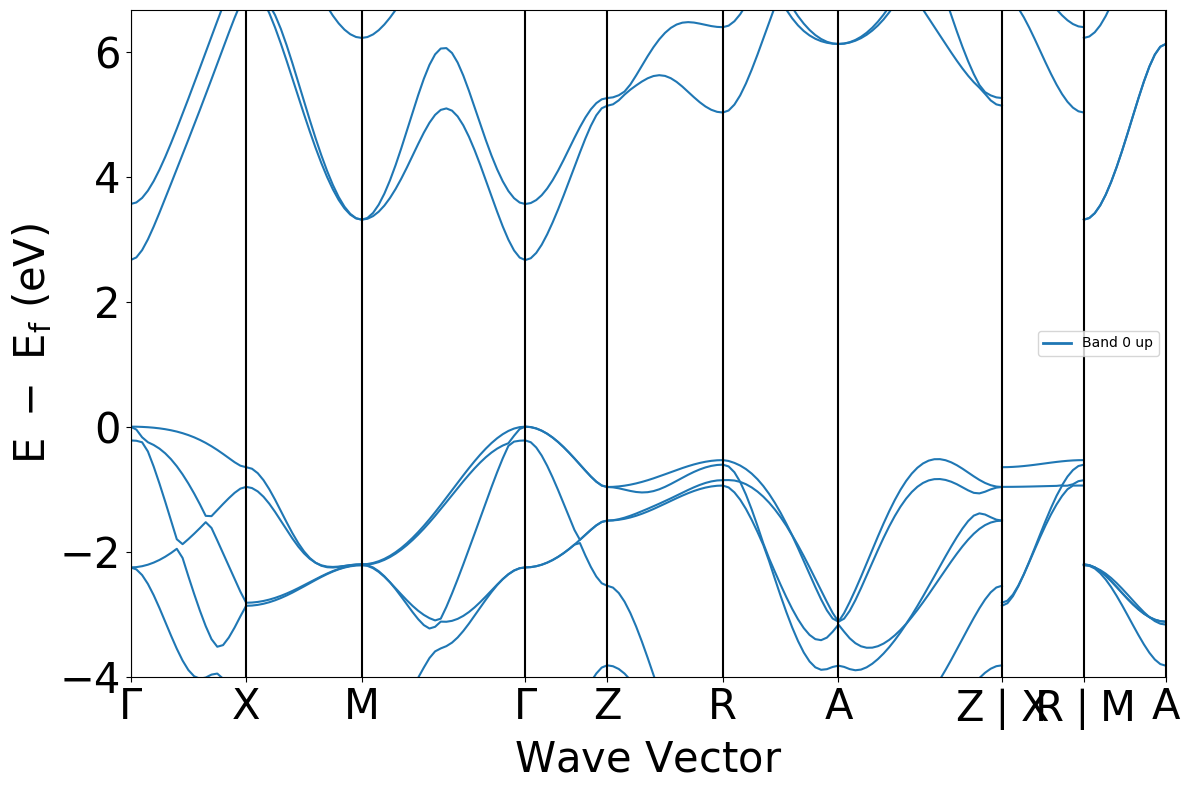

In [2]:
plot_bandstructure = BSPlotter(el_bandstructure)
plot_bandstructure.get_plot()

## 3.2 Bande interdite 

La largeur de la bande interdite (= énergie de la bande) est de: 2.6642 eV
La bande interdite se situe donc entre 0 eV et 2.6642 eV.
La bande interdite de ce matériau est direct
La transistion est en: \Gamma-\Gamma


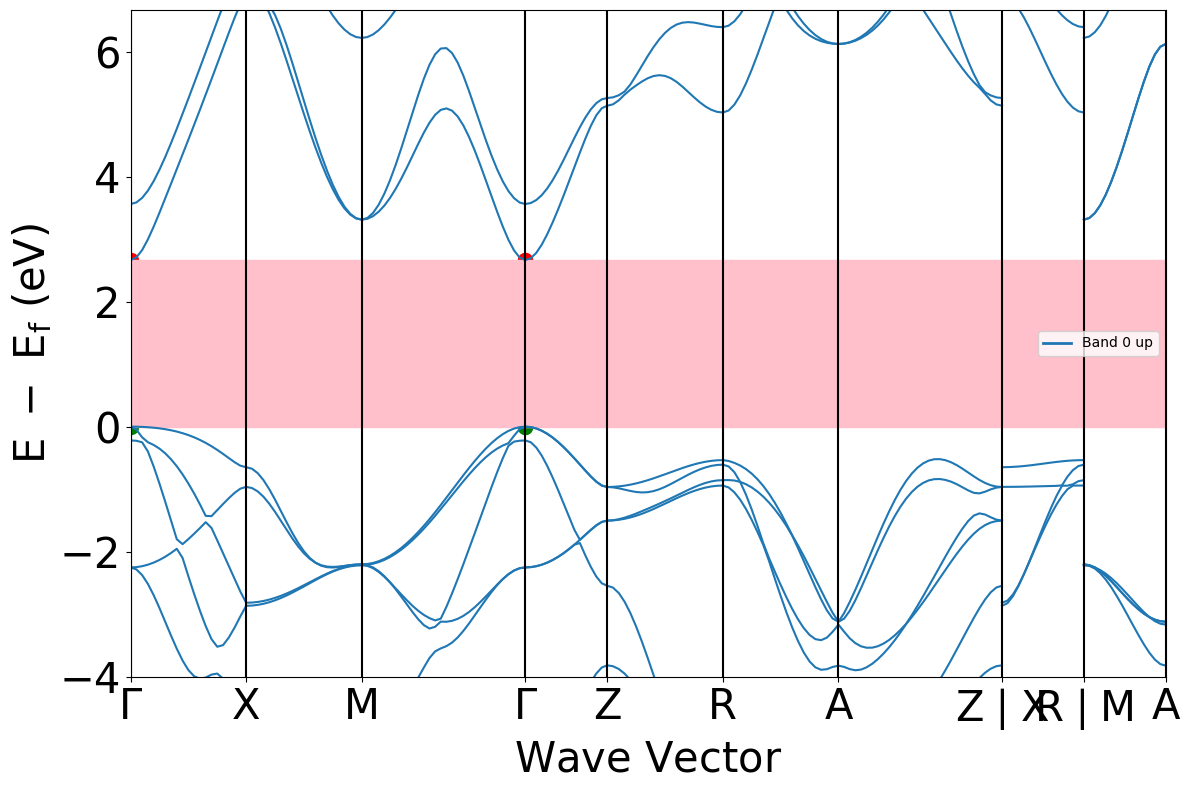

In [3]:
band_int = el_bandstructure.get_band_gap()
plot_bandstructure = BSPlotter(el_bandstructure) 

data = plot_bandstructure.bs_plot_data()
gap_energy = band_int.get('energy')

distance = data.get('ticks').get('distance')

plot_bandstructure.get_plot(vbm_cbm_marker=True)

plt.fill_between(np.linspace(distance[0], distance[-1], 2), 0, gap_energy,color = "pink")


print("La largeur de la bande interdite (= énergie de la bande) est de:", band_int["energy"],"eV")
print('La bande interdite se situe donc entre 0 eV et {} eV.'.format(gap_energy))

if band_int["direct"] is True:
    print("La bande interdite de ce matériau est direct")
if band_int["direct"] is False:
    print("La bande interdite de ce matériau est indirect")

print("La transistion est en:", band_int["transition"])

La bande interdite (ou gap de bande) est l’intervalle énergétique entre le sommet de la bande de valence et la base de la bande de conduction dans un matériau. Dans un cristal, les électrons ne possèdent pas n’importe quelle énergie : à cause du potentiel périodique créé par l’arrangement régulier des atomes, les niveaux électroniques se réorganisent en bandes d’énergie permises séparées, dans certains cas, par des bandes interdites. 

Dans le cas de notre matériau (AlGaN2), l’énergie de la bande interdite vaut 2.6642 eV. Cette valeur mesure l’énergie minimale nécessaire pour faire passer un électron de la bande de valence à la bande de conduction, et ainsi contribuer à la conduction électrique. La présence d’un gap non nul montre donc que le matériau n’est pas métallique, il se comporte comme un semi-conducteur. Les électrons doivent recevoir une certaine énergie avant de pouvoir participer au transport électrique.

La bande interdite ici est directe, ce qui signifie que le maximum de la bande de valence (VBM) et le minimum de la bande de conduction (CBM) se trouvent au même vecteur d’onde k. Dans notre cas, la transition a lieu en Γ−Γ, c’est-à-dire au centre de la zone de Brillouin. Cela signifie qu’un électron peut passer de la bande de valence à la bande de conduction sans changement de quantité de mouvement.


## 3.3 Dispersion 

La dispersion dans les bandes de conduction et de valence décrit comment l’énergie des électrons varie en fonction de leur vecteur d’onde k. Cette relation, notée E(k), influence directement la mobilité des électrons et les propriétés de transport électrique d’un matériau. Un électron se déplace dans un matériau avec une vitesse de groupe proportionnelle à la pente de E(k). Plus cette pente est prononcée, plus l’électron est mobile. À l’inverse, une pente faible traduit une dispersion réduite et une mobilité plus limitée.

Dans un diagramme de bandes électroniques, une forte dispersion correspond à une bande inclinée, indiquant que les électrons peuvent se déplacer rapidement, une caractéristique favorable à la conductivité. En revanche, une bande plate reflète une faible dispersion, suggérant que les électrons sont plus localisés et moins aptes à se déplacer librement.

### 1) Première bande de conduction 

In [4]:
cbm = el_bandstructure.get_cbm()
print(cbm["band_index"])

defaultdict(<class 'list'>, {<Spin.up: 1>: [13]})


La bande 13 est la première bande de conduction.

### 2) Dernière bande de valence 

In [5]:
vbm = el_bandstructure.get_vbm()
print(vbm["band_index"])

defaultdict(<class 'list'>, {<Spin.up: 1>: [11, 12]})


La bande 11 est la dernière bande de valence.

### 3) Calcul des directions 

In [6]:
distances = data['distances']
energy = data['energy']

vbm_band_index = el_bandstructure.get_vbm()['band_index'][Spin.up][-1]   # dernière bande de valence
cbm_band_index = el_bandstructure.get_cbm()['band_index'][Spin.up][0]    # première bande de conduction

Valence = []
Conduction = []

for i in range(len(distances)):
    dx = distances[i][-1] - distances[i][0]

    dy_Valence = energy['1'][i][vbm_band_index][-1] - energy['1'][i][vbm_band_index][0]
    dy_Conduction = energy['1'][i][cbm_band_index][-1] - energy['1'][i][cbm_band_index][0]

    slope_Valence = abs(dy_Valence / dx)
    slope_Conduction = abs(dy_Conduction / dx)

    Valence.append(slope_Valence)
    Conduction.append(slope_Conduction)

Valence_max = Valence.index(max(Valence))
Valence_min = Valence.index(min(Valence))
Cond_max = Conduction.index(max(Conduction))
Cond_min = Conduction.index(min(Conduction))

print("Sur la dernière bande de valence, la plus grande dispersion se trouve sur le chemin d'indice", Valence_max)
print("Sur la dernière bande de valence, la plus petite dispersion se trouve sur le chemin d'indice", Valence_min)
print("Sur la première bande de conduction, la plus grande dispersion se trouve sur le chemin d'indice", Cond_max)
print("Sur la première bande de conduction, la plus petite dispersion se trouve sur le chemin d'indice", Cond_min)



Sur la dernière bande de valence, la plus grande dispersion se trouve sur le chemin d'indice 5
Sur la dernière bande de valence, la plus petite dispersion se trouve sur le chemin d'indice 7
Sur la première bande de conduction, la plus grande dispersion se trouve sur le chemin d'indice 0
Sur la première bande de conduction, la plus petite dispersion se trouve sur le chemin d'indice 4


In [ ]:
plot_bandstructure.get_plot(vbm_cbm_marker=True)

vbm_band_index = el_bandstructure.get_vbm()['band_index'][Spin.up][-1]  # Dernière bande de valence
cbm_band_index = el_bandstructure.get_cbm()['band_index'][Spin.up][0]   # Première bande de conduction


for i in range(len(distances)):
    plt.plot(distances[i], energy.get('1')[i][vbm_band_index], 'green') 
    plt.plot(distances[i], energy.get('1')[i][cbm_band_index], 'red') 


cbm_coord = data.get('cbm')
for (x, y) in cbm_coord:
    plt.plot(x, y, 'or', markersize=8)  


vbm_coord = data.get('vbm')
for (x, y) in vbm_coord:
    plt.plot(x, y, 'og', markersize=8)  


# Bande de valence avec la plus petite dispertion
plt.arrow(distances[Valence_min][0],
    energy['1'][Valence_min][vbm_band_index][0],
    distances[Valence_min][-1] - distances[Valence_min][0],
    energy['1'][Valence_min][vbm_band_index][-1] - energy['1'][Valence_min][vbm_band_index][0],
    width=0.03,
    length_includes_head=True,
    color='blue')


# Bande de valence avec la plus grande dispertion
plt.arrow(distances[Valence_max][0],
    energy['1'][Valence_max][vbm_band_index][0],
    distances[Valence_max][-1] - distances[Valence_max][0],
    energy['1'][Valence_max][vbm_band_index][-1] - energy['1'][Valence_max][vbm_band_index][0],
    width=0.03,
    length_includes_head=True,
    color='red')

# Bande de conduction avec la plus petite dispertion
plt.arrow(distances[Cond_min][0],
    energy['1'][Cond_min][cbm_band_index][0],
    distances[Cond_min][-1] - distances[Cond_min][0],
    energy['1'][Cond_min][cbm_band_index][-1] - energy['1'][Cond_min][cbm_band_index][0],
    width=0.03,
    length_includes_head=True,
    color='blue')

# Bande de conduction avec la plus grande dispertion
plt.arrow(distances[Cond_max][0],
    energy['1'][Cond_max][cbm_band_index][0],
    distances[Cond_max][-1] - distances[Cond_max][0],
    energy['1'][Cond_max][cbm_band_index][-1] - energy['1'][Cond_max][cbm_band_index][0],
    width=0.03,
    length_includes_head=True,
    color='red')


plt.show()

## 3.6 Masse effective

Dans un cristal, les électrons ne se comportent pas exactement comme des particules libres. 
En effet, ils évoluent dans le potentiel périodique créé par le réseau cristallin. 
Pour décrire leur dynamique de manière simple, on introduit la notion de **masse effective**.

L’idée consiste à décrire les électrons comme des particules libres dont la masse est remplacée 
par une **masse effective m*** qui dépend de la structure de bande du matériau.

En toute généralité, la masse effective est définie à partir du tenseur des dérivées secondes 
de l’énergie \(E\) par rapport au vecteur d’onde \(k\) :

\[
m^{*}_{ij} =
\left(
\frac{\partial^2 E}{\partial k_i \partial k_j}
\right)^{-1}
\]

Cette relation montre que la masse effective dépend de la **courbure de la bande électronique**.

- Si la bande est **très courbée**, la dérivée seconde est grande et la masse effective est **petite**.
- Si la bande est **plate**, la dérivée seconde est faible et la masse effective est **grande**.

Ainsi :
- une **petite masse effective** correspond à des électrons très mobiles
- une **grande masse effective** correspond à des électrons plus localisés

Dans la pratique, près du minimum de la bande de conduction (CBM) ou du maximum de la bande 
de valence (VBM), la dispersion peut être approximée par une **parabole** :

\[
E(k) \approx E_0 + \frac{\hbar^2 k^2}{2m^*}
\]

En dérivant deux fois cette relation, on obtient la formule utilisée pour calculer la masse effective :

\[
m^* =
\frac{\hbar^2}{\frac{d^2E}{dk^2}}
\]

Nous allons utiliser cette approximation pour déterminer la masse effective au sommet de la 
bande de valence et à la base de la bande de conduction.

In [7]:
hbarre = 6.62607015e-34/(2*np.pi)  # J.s
eV = 1.6022e-19                    # eV -> J
A = 1e-10                          # angström -> m

# choisir un segment autour de Gamma
k = np.array(distances[0])

E_val = np.array(energy['1'][0][vbm_band_index])
E_cond = np.array(energy['1'][0][cbm_band_index])

# prendre quelques points autour du minimum / maximum
k_points = k[:6]
E_val_points = E_val[:6]
E_cond_points = E_cond[:6]

# fit parabolique
coeff_val = np.polyfit(k_points, E_val_points, 2)
coeff_cond = np.polyfit(k_points, E_cond_points, 2)

a_val = coeff_val[0]
a_cond = coeff_cond[0]

# conversion correcte des unités
d2E_dk2_val = 2 * a_val * eV * A**2
d2E_dk2_cond = 2 * a_cond * eV * A**2

# masse effective
m_val = hbarre**2 / d2E_dk2_val
m_cond = hbarre**2 / d2E_dk2_cond

print("Masse effective valence :", m_val, "kg")
print("Masse effective conduction :", m_cond, "kg")

Masse effective valence : -7.377301247120578e-30 kg
Masse effective conduction : 3.831214298936625e-31 kg


La masse effective de conduction obtenue est de l’ordre de 
0.4me, ce qui est cohérent avec un semi-conducteur. La masse effective associée à la bande de valence est négative, comme attendu pour un maximum de bande, et de grande valeur absolue, suggérant des trous lourds. Cette estimation reste toutefois sensible au choix du segment et à la fenêtre de points utilisée pour le fit parabolique.